In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# Import data
df = pd.read_csv("earnings_panel_with_CAR_p5_p20_20260224.csv")

In [3]:
df.head()

,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,totalRevenue,grossProfit,...,profitability_regime,margin_trend_regime,financial_strength_regime,event_id_reported,event_id_y,CAR_m1_p1,CAR_m2_p2,CAR_m5_p5,CAR_p5_p20,eps_bin2
0,2005-09-30,2005-10-11,0.01,0.01,0.0,0.0,post-market,AAPL,3678000000,1035000000,...,medium,missing,mixed,AAPL_2005-10-11,AAPL_2005-10-11,0.007234,0.077716,0.057094,0.017414,0
1,2005-12-31,2006-01-18,0.02,0.02,0.0,0.0,post-market,AAPL,5749000000,1564000000,...,medium,contraction,mixed,AAPL_2006-01-18,AAPL_2006-01-18,-0.075341,-0.062981,-0.036115,-0.144021,0
2,2006-03-31,2006-04-19,0.02,0.02,0.0,0.0,post-market,AAPL,4359000000,1297000000,...,medium,stable,mixed,AAPL_2006-04-19,AAPL_2006-04-19,0.015041,0.012303,-0.003040,0.059703,0
3,2006-06-30,2006-07-19,0.02,0.02,0.0,0.0,post-market,AAPL,4370000000,1325000000,...,medium,expansion,mixed,AAPL_2006-07-19,AAPL_2006-07-19,0.146301,0.199178,0.163703,0.045687,0
4,2006-09-30,2006-10-18,0.02,0.02,0.0,0.0,post-market,AAPL,4370000000,1412000000,...,medium,expansion,mixed,AAPL_2006-10-18,AAPL_2006-10-18,0.057448,0.068848,0.062844,-0.031069,0


In [4]:
# Ensure reportedDate is a proper datetime
df["reportedDate"] = pd.to_datetime(df["reportedDate"], errors="coerce")

In [5]:
# Standardise column names: regimes → categories
rename_map = {
    "eps_surprise_regime": "eps_surprise_category",
    "profitability_regime": "profitability_category",
    "margin_trend_regime": "margin_trend_category"
}

# Only rename columns that actually exist (safe)
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Optional sanity check
print("Renamed columns present:")
for col in rename_map.values():
    print(col, "→", col in df.columns)

Renamed columns present:
eps_surprise_category → True
profitability_category → True
margin_trend_category → True


In [6]:
# Create the correct analysis dataframe
START_DATE = "2022-01-01"
END_DATE   = "2025-12-31"

df_analysis = df[
    (df["reportedDate"] >= START_DATE) &
    (df["reportedDate"] <= END_DATE)
].copy()

print("Date range:", df_analysis["reportedDate"].min(), "to", df_analysis["reportedDate"].max())
print("Rows:", len(df_analysis))
print(df_analysis["symbol"].value_counts(dropna=False))

Date range: 2022-01-27 00:00:00 to 2025-11-19 00:00:00
Rows: 48
symbol
AAPL     16
GOOGL    16
NVDA     16
Name: count, dtype: int64


In [7]:
# Create merged categories on df_analysis
df_analysis["eps_surprise_category_3"] = df_analysis["eps_surprise_category"].map({
    "large_negative": "negative",
    "moderate_negative": "negative",
    "small": "neutral",
    "moderate_positive": "positive",
    "large_positive": "positive"
})

# Optional quick check
print(df_analysis["eps_surprise_category_3"].value_counts(dropna=False))

eps_surprise_category_3
positive    33
neutral      9
negative     6
Name: count, dtype: int64


In [8]:
# Define CAR columns
signal_car_col = "CAR_m5_p5"     # −5 to +5
drift_car_col  = "CAR_p5_p20"    # +5 to +20

In [9]:
df_analysis[["symbol","reportedDate","CAR_m5_p5","CAR_p5_p20"]].head()

,symbol,reportedDate,CAR_m5_p5,CAR_p5_p20
65,AAPL,2022-01-27,0.025724,-0.004822
66,AAPL,2022-04-28,-0.010892,-0.061304
67,AAPL,2022-07-28,0.001655,0.041474
68,AAPL,2022-10-27,0.017646,-0.067417
69,AAPL,2023-02-02,0.012381,0.023052


In [10]:
# Helper cell
import matplotlib.pyplot as plt

def plot_mean_car_by_category(
    df,
    symbol,
    category_col,
    car_col,
    title_suffix="",
    category_order=None,
    ylim=None
):
    d = df[df["symbol"] == symbol].copy()
    d = d.dropna(subset=[category_col, car_col])

    means = d.groupby(category_col)[car_col].mean()

    if category_order is not None:
        means = means.reindex(category_order)

    plt.figure(figsize=(6, 4))
    means.plot(kind="bar")
    plt.ylim(shared_ylim)
    plt.axhline(0, linewidth=1)
    plt.title(f"{symbol}: Mean {car_col} by {category_col} {title_suffix}")
    plt.ylabel("Mean CAR")
    plt.xlabel(category_col)

    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()

    return list(means.index)

In [11]:
# Select the CAR window.
car_col = "CAR_m5_p5"

# Select the EPS surprise category
eps_col = "eps_surprise_category_3"

# Drop missing EPS categories
df_eps = df_analysis.dropna(subset=[eps_col])

# Aggregate mean CAR by EPS category (for all firms)
summary_eps_all = (
    df_eps
    .groupby(eps_col)[car_col]
    .agg(
        mean_car="mean",
        n_events="size"
    )
    .reset_index()
)

# Compute overall baseline (all events, all firms)
baseline_all = df_eps[car_col].mean()

# Inspect the results
summary_eps_all.sort_values("mean_car")

,eps_surprise_category_3,mean_car,n_events
1,neutral,-0.016743,9
0,negative,-0.015422,6
2,positive,0.011969,33


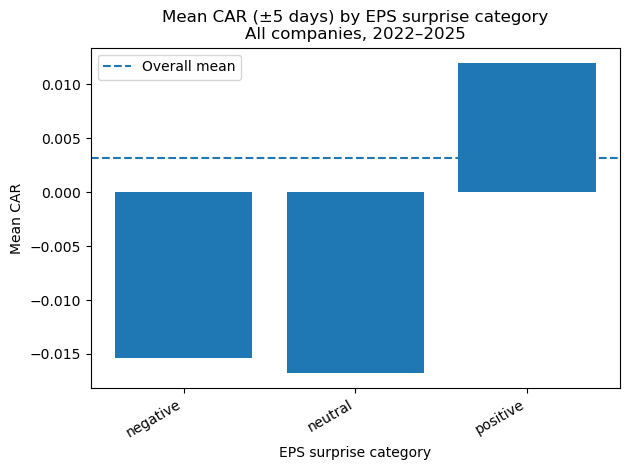

In [12]:
# Plot the chart
plt.figure()
plt.bar(
    summary_eps_all[eps_col].astype(str),
    summary_eps_all["mean_car"]
)
plt.axhline(
    baseline_all,
    linestyle="--",
    label="Overall mean"
)
plt.title("Mean CAR (±5 days) by EPS surprise category\nAll companies, 2022–2025")
plt.ylabel("Mean CAR")
plt.xlabel("EPS surprise category")

plt.xticks(rotation=30, ha="right")

plt.legend()
plt.tight_layout()
plt.savefig("eps.png", dpi=300, bbox_inches="tight")
plt.show()

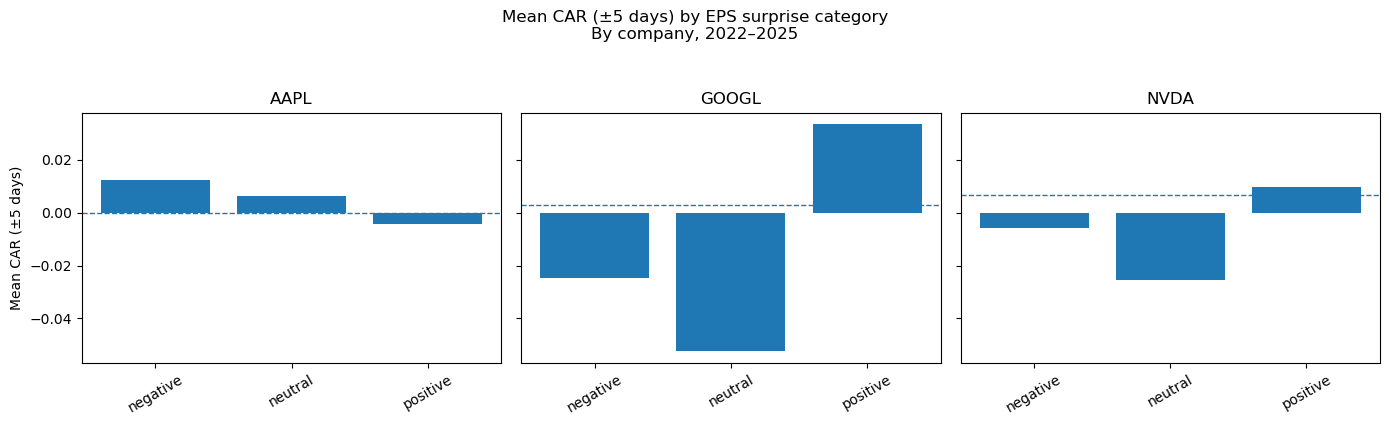

In [13]:
import matplotlib.pyplot as plt

tickers = sorted(df_eps["symbol"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tickers),
    figsize=(14, 4),
    sharey=True
)

for ax, ticker in zip(axes, tickers):
    df_t = df_eps[df_eps["symbol"] == ticker]

    summary = (
        df_t
        .groupby("eps_surprise_category_3")[car_col]
        .agg(mean_car="mean", n_events="size")
        .reset_index()
    )

    # enforce category order
    cat_order = ["negative", "neutral", "positive"]
    summary["eps_surprise_category_3"] = pd.Categorical(
        summary["eps_surprise_category_3"],
        categories=cat_order,
        ordered=True
    )
    summary = summary.sort_values("eps_surprise_category_3")

    baseline = df_t[car_col].mean()

    ax.bar(summary["eps_surprise_category_3"], summary["mean_car"])
    ax.axhline(baseline, linestyle="--", linewidth=1)

    ax.set_title(ticker)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Mean CAR (±5 days)")
fig.suptitle(
    "Mean CAR (±5 days) by EPS surprise category\nBy company, 2022–2025",
    y=1.05
)

plt.tight_layout()
plt.savefig("eps_surprise_by_firm.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations
For Apple, EPS surprises do not translate cleanly into short-term abnormal returns in the current regime.

EPS still matters for Google, but only on the upside.

For NVIDIA, only clearly positive earnings reinforce momentum; anything less is penalised.

In [14]:
# Set consistent y axis across the two charts
symbol = "GOOGL"
category_col = "eps_surprise_category_3"
order = ["negative", "neutral", "positive"]

d = (
    df_eps[df_eps["symbol"] == symbol]
    .dropna(subset=[category_col, signal_car_col, drift_car_col])
    .copy()
)

means_signal = d.groupby(category_col)[signal_car_col].mean().reindex(order)
means_drift  = d.groupby(category_col)[drift_car_col].mean().reindex(order)

ymin = min(means_signal.min(), means_drift.min())
ymax = max(means_signal.max(), means_drift.max())
pad = 0.1 * (ymax - ymin) if ymax > ymin else 0.01

shared_ylim = (ymin - pad, ymax + pad)

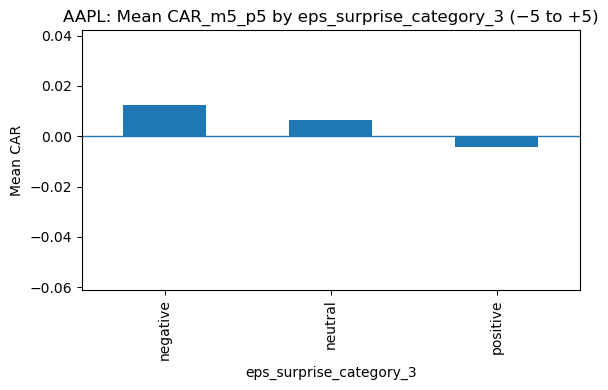

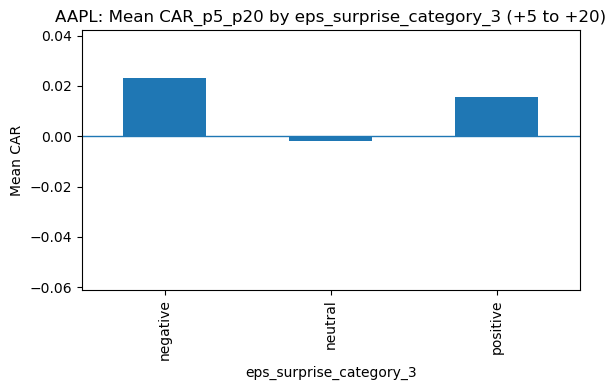

In [15]:
symbol = "AAPL"
category_col = "eps_surprise_category_3"

order = plot_mean_car_by_category(
    df_eps,   
    symbol=symbol,
    category_col=category_col,
    car_col=signal_car_col,
    title_suffix="(−5 to +5)",
    category_order=["negative", "neutral", "positive"]  
)

_ = plot_mean_car_by_category(
    df_eps,   # <-- use df_eps, not df
    symbol=symbol,
    category_col=category_col,
    car_col=drift_car_col,
    title_suffix="(+5 to +20)",
    category_order=["negative", "neutral", "positive"]  
)

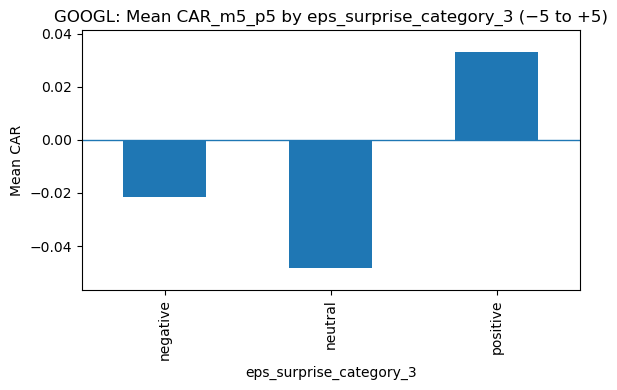

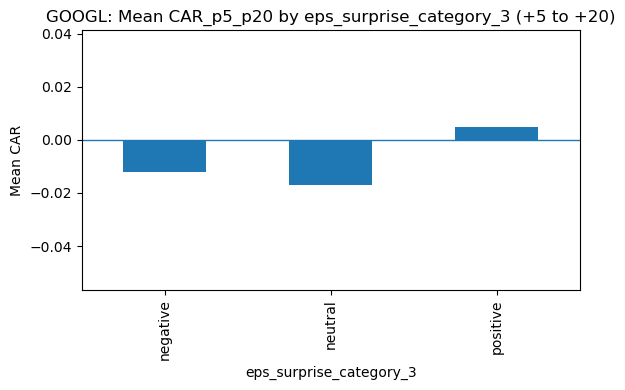

In [15]:
symbol = "GOOGL"
category_col = "eps_surprise_category_3"

order = plot_mean_car_by_category(
    df_eps,   # <-- use df_eps, not df
    symbol=symbol,
    category_col=category_col,
    car_col=signal_car_col,
    title_suffix="(−5 to +5)",
    category_order=["negative", "neutral", "positive"]  # optional but helps
)

_ = plot_mean_car_by_category(
    df_eps,   # <-- use df_eps, not df
    symbol=symbol,
    category_col=category_col,
    car_col=drift_car_col,
    title_suffix="(+5 to +20)",
    category_order=["negative", "neutral", "positive"]  # optional but helps
)

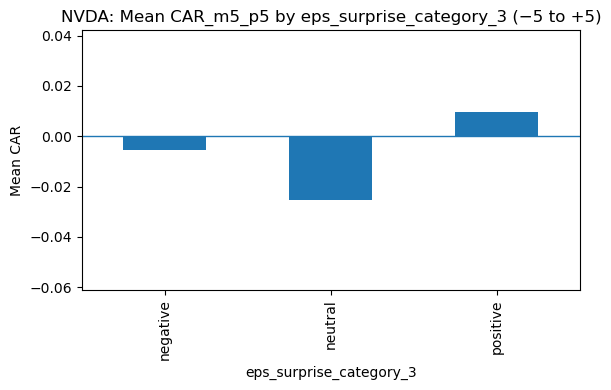

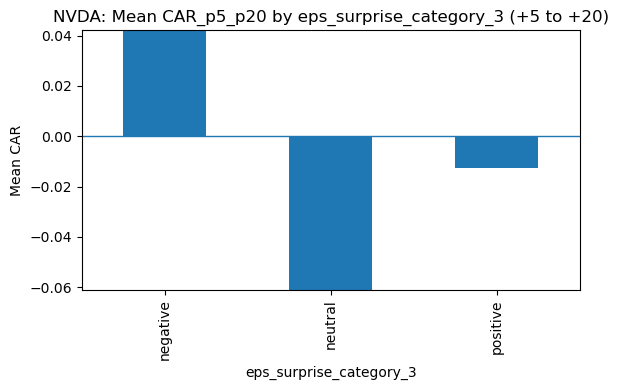

In [16]:
symbol = "NVDA"
category_col = "eps_surprise_category_3"

order = plot_mean_car_by_category(
    df_eps,   # <-- use df_eps, not df
    symbol=symbol,
    category_col=category_col,
    car_col=signal_car_col,
    title_suffix="(−5 to +5)",
    category_order=["negative", "neutral", "positive"]  # optional but helps
)

_ = plot_mean_car_by_category(
    df_eps,   # <-- use df_eps, not df
    symbol=symbol,
    category_col=category_col,
    car_col=drift_car_col,
    title_suffix="(+5 to +20)",
    category_order=["negative", "neutral", "positive"]  # optional but helps
)

### Observations
Comparing mean CAR across the two event windows shows that Apple’s immediate earnings reaction (−5 to +5) is noisy and expectation-driven, with EPS surprise categories not consistently predicting short-term returns. In contrast, over the post-earnings window (+5 to +20), events with meaningful EPS surprises (both positive and negative) are followed by positive price drift, while neutral earnings show little follow-through. This suggests that for Apple in the current market regime, EPS surprises are more informative for post-earnings behaviour than for the initial reaction, supporting their use as a conditioning signal for longer-horizon trading strategies.

In [17]:
# Set the metric to profitabilty
metric_col = "profitability_category"

# Drop missing profitability categories
df_prof = df_analysis.dropna(subset=[metric_col]).copy()

# Check the output.
df_prof[metric_col].value_counts()

profitability_category
high      41
medium     6
low        1
Name: count, dtype: int64

In [18]:
# Aggregate mean CAR by profitability
summary_prof_all = (
    df_prof
    .groupby(metric_col)[car_col]
    .agg(
        mean_car="mean",
        n_events="size"
    )
    .reset_index()
)

# Inspect results.
summary_prof_all.sort_values("mean_car")

,profitability_category,mean_car,n_events
1,low,-0.025387,1
0,high,0.003116,41
2,medium,0.008229,6


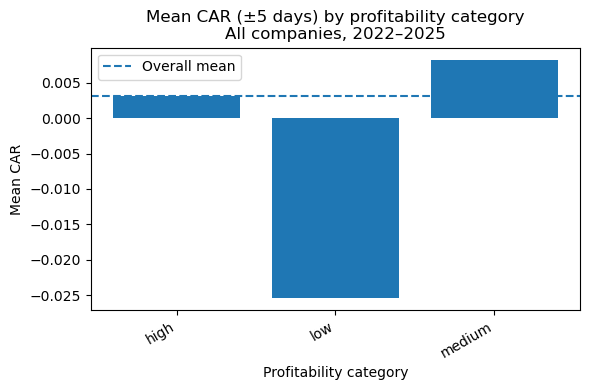

In [19]:
# Compute baseline
baseline_all = df_prof[car_col].mean()

# Plot the aggregate profitability chart
plt.figure(figsize=(6, 4))
plt.bar(
    summary_prof_all[metric_col].astype(str),
    summary_prof_all["mean_car"]
)
plt.axhline(
    baseline_all,
    linestyle="--",
    label="Overall mean"
)

plt.title(
    "Mean CAR (±5 days) by profitability category\nAll companies, 2022–2025"
)
plt.ylabel("Mean CAR")
plt.xlabel("Profitability category")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Observations
At an aggregate level, profitability does not show a simple “higher is better” relationship with short-term post-earnings returns, likely because highly profitable firms already have strong expectations priced in. The stronger reactions seen for medium-profitability firms suggest that earnings updates for these companies lead to larger revisions in investor expectations, while low-profitability firms are generally penalised.

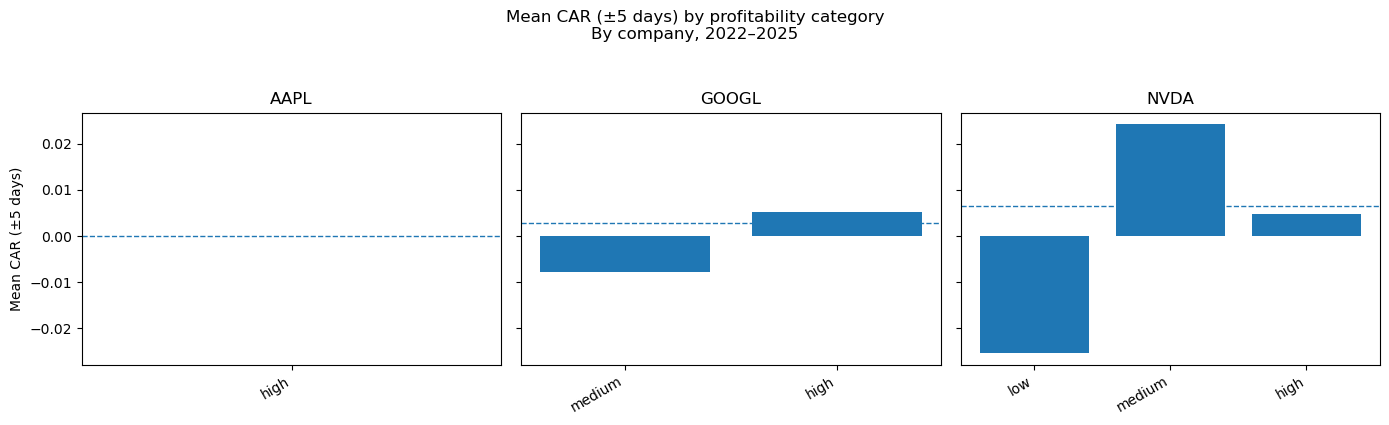

In [20]:
# Plot mean CAR by profitability by company

tickers = sorted(df_prof["symbol"].unique())
cat_order = ["low", "medium", "high"]

fig, axes = plt.subplots(1, len(tickers), figsize=(14, 4), sharey=True)

# Ensure axes is iterable
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = df_prof[df_prof["symbol"] == ticker]

    summary = (
        df_t
        .groupby("profitability_category")[car_col]
        .agg(mean_car="mean", n_events="size")
        .reset_index()
    )

    # enforce category order
    summary["profitability_category"] = pd.Categorical(
        summary["profitability_category"],
        categories=cat_order,
        ordered=True
    )
    summary = summary.sort_values("profitability_category")

    x = range(len(summary))
    baseline = df_t[car_col].mean()

    bars = ax.bar(x, summary["mean_car"])
    ax.axhline(baseline, linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(summary["profitability_category"], rotation=30, ha="right")
    ax.set_title(ticker)

    axes[0].set_ylabel("Mean CAR (±5 days)")

fig.suptitle(
    "Mean CAR (±5 days) by profitability category\nBy company, 2022–2025",
    y=1.05
)

plt.tight_layout()
plt.savefig("profitability_by_firm.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations
Profitability affects post-earnings returns in a firm-specific way. While it matters little for Apple, it plays a clearer role for Google and a highly non-linear role for NVIDIA, reflecting differences in growth stage and investor expectations.

In [21]:
# Set column to margin trend
metric_col = "margin_trend_category"

# Drop missing values
df_margin = df_analysis.dropna(subset=[metric_col]).copy()

# Aggregate all firms
summary_margin_all = (
    df_margin
    .groupby(metric_col)[car_col]
    .agg(mean_car="mean", n_events="size")
    .reset_index()
)

baseline_all = df_margin[car_col].mean()

summary_margin_all.sort_values("mean_car")

,margin_trend_category,mean_car,n_events
0,contraction,-0.017567,22
2,stable,-0.014735,3
1,expansion,0.027568,23


In [22]:
# Plot aggregate margin trend chart
plt.figure(figsize=(6, 4))
plt.bar(
    summary_margin_all[metric_col].astype(str),
    summary_margin_all["mean_car"]
)
plt.axhline(
    baseline_all,
    linestyle="--",
    label="Overall mean"
)

plt.title(
    "Mean CAR (±5 days) by margin trend\nAll companies, 2022–2025"
)
plt.ylabel("Mean CAR")
plt.xlabel("Margin trend")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'summary_margin_all' is not defined

<Figure size 600x400 with 0 Axes>

In [23]:
# Break out by firm
tickers = sorted(df_margin["symbol"].unique())
cat_order = ["contraction", "stable", "expansion"]

fig, axes = plt.subplots(1, len(tickers), figsize=(14, 4), sharey=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = df_margin[df_margin["symbol"] == ticker]

    summary = (
        df_t
        .groupby(metric_col)[car_col]
        .agg(mean_car="mean", n_events="size")
        .reset_index()
    )

    summary[metric_col] = pd.Categorical(
        summary[metric_col],
        categories=cat_order,
        ordered=True
    )
    summary = summary.sort_values(metric_col)

    x = range(len(summary))
    baseline = df_t[car_col].mean()

    ax.bar(x, summary["mean_car"])
    ax.axhline(baseline, linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(summary[metric_col], rotation=30, ha="right")
    ax.set_title(ticker)

axes[0].set_ylabel("Mean CAR (±5 days)")
fig.suptitle(
    "Mean CAR (±5 days) by margin trend\nBy company, 2022–2025",
    y=1.05
)
plt.tight_layout()
plt.savefig("margin_trend_by_firm.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'df_margin' is not defined

### Observations
Margin trends show a clear relationship with short-term post-earnings returns, particularly in the current tightening environment, where margin expansion is consistently rewarded and contraction is penalised. The strength of this effect varies by firm, with especially strong responses for NVIDIA and clearer signals for Google than for Apple, reinforcing the need for ticker-specific analysis rather than a uniform earnings strategy.

In [24]:
symbol = "NVDA"
category_col = "margin_trend_category"
category_order = ["contraction", "stable", "expansion"]

In [25]:
df_margin = df_analysis.dropna(subset=[category_col, signal_car_col, drift_car_col]).copy()

In [26]:
d = df_margin[df_margin["symbol"] == symbol].copy()

means_signal = d.groupby(category_col)[signal_car_col].mean().reindex(category_order)
means_drift  = d.groupby(category_col)[drift_car_col].mean().reindex(category_order)

ymin = min(means_signal.min(), means_drift.min())
ymax = max(means_signal.max(), means_drift.max())

pad = 0.1 * (ymax - ymin) if pd.notna(ymax) and pd.notna(ymin) and ymax > ymin else 0.01
shared_ylim = (ymin - pad, ymax + pad)

print(means_signal)
print(means_drift)
print("shared_ylim:", shared_ylim)

margin_trend_category
contraction   -0.024530
stable        -0.075591
expansion      0.034140
Name: CAR_m5_p5, dtype: float64
margin_trend_category
contraction   -0.025068
stable        -0.147030
expansion      0.003341
Name: CAR_p5_p20, dtype: float64
shared_ylim: (-0.16514706343009733, 0.05225705097070403)


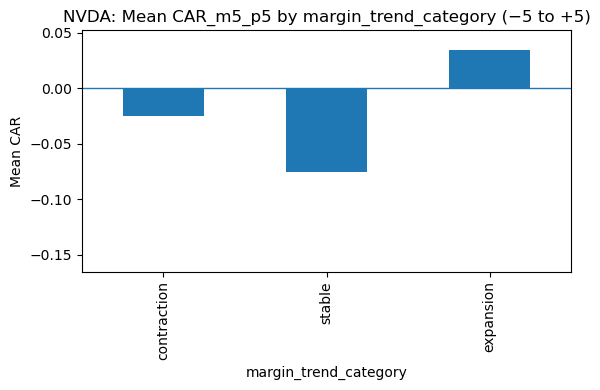

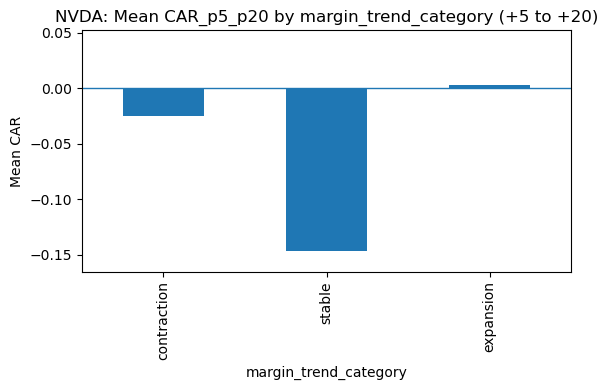

In [27]:
_ = plot_mean_car_by_category(
    df_margin,
    symbol=symbol,
    category_col=category_col,
    car_col=signal_car_col,
    title_suffix="(−5 to +5)",
    category_order=category_order
)

_ = plot_mean_car_by_category(
    df_margin,
    symbol=symbol,
    category_col=category_col,
    car_col=drift_car_col,
    title_suffix="(+5 to +20)",
    category_order=category_order
)